## EJERCICIO 1

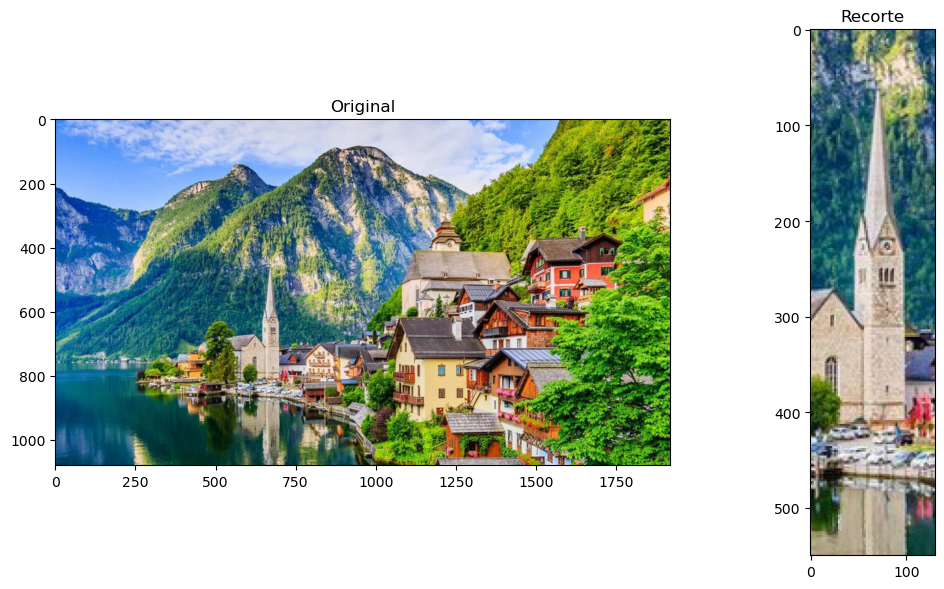

In [41]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

#imagenes colocadas
img = cv2.imread('imagen1.jpg')
img1 = cv2.imread('imagen2.jpg')

#convertir a RGB
imgRGB = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img1RGB = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)

#Colocar axis mas recorte 
fig, axes = plt.subplots(1,2, figsize=(12,6))
axes[0].imshow(img1RGB)
axes[0].set_title('Original')
axes[0].axis('on')
axes[1].imshow(img1RGB[400:950,600:730])
axes[1].set_title('Recorte')
axes[1].axis('on')
plt.tight_layout()
plt.show()



## EJERCICIO 2 

<Figure size 600x800 with 0 Axes>

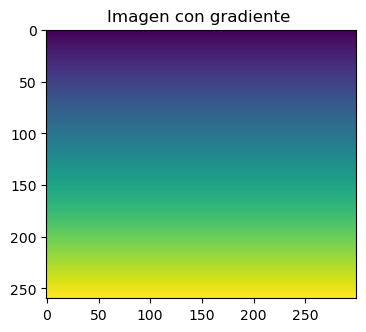

In [98]:
import numpy as np
import matplotlib.pyplot as plt

h,w = 260,300
img = plt.get_cmap('viridis')(np.linspace(0,1,h))[:,:3]         
img = np.tile(img[:,None,:], (1,w,1))   

#Guardar imagen
plt.imsave('gradiente.png', img)
                
plt.tight_layout()
plt.show()
plt.figure(figsize=(4,6)); 
plt.imshow(img); 
plt.title('Imagen con gradiente ');
plt.show()

## EJERCICIO 3

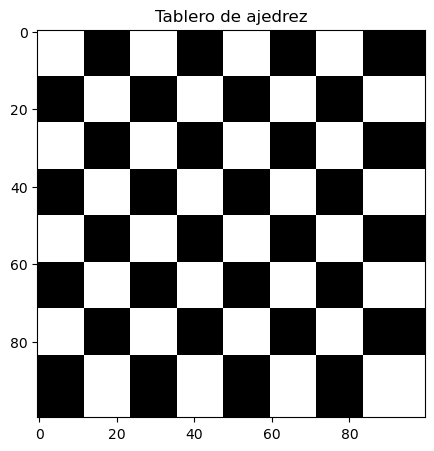

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

size_imagen = 100
rows, cols = 8, 8
cell_h = size_imagen // rows
cell_w = size_imagen // cols

imagen = np.zeros((size_imagen, size_imagen, 3), dtype=np.uint8)

for i in range(rows):
    for j in range(cols):
        y0 = i * cell_h
        x0 = j * cell_w
        y1 = (i + 1) * cell_h if i < rows - 1 else size_imagen
        x1 = (j + 1) * cell_w if j < cols - 1 else size_imagen
        color = [255,255,255] if (i + j) % 2 == 0 else [0,0,0]  
        imagen[y0:y1, x0:x1] = color

plt.figure(figsize=(5,6))
plt.title('Tablero de ajedrez')
plt.imshow(imagen)
plt.show()

## EJERCICIO 4

TODOS LOS FALSO COLOR (FALTA)

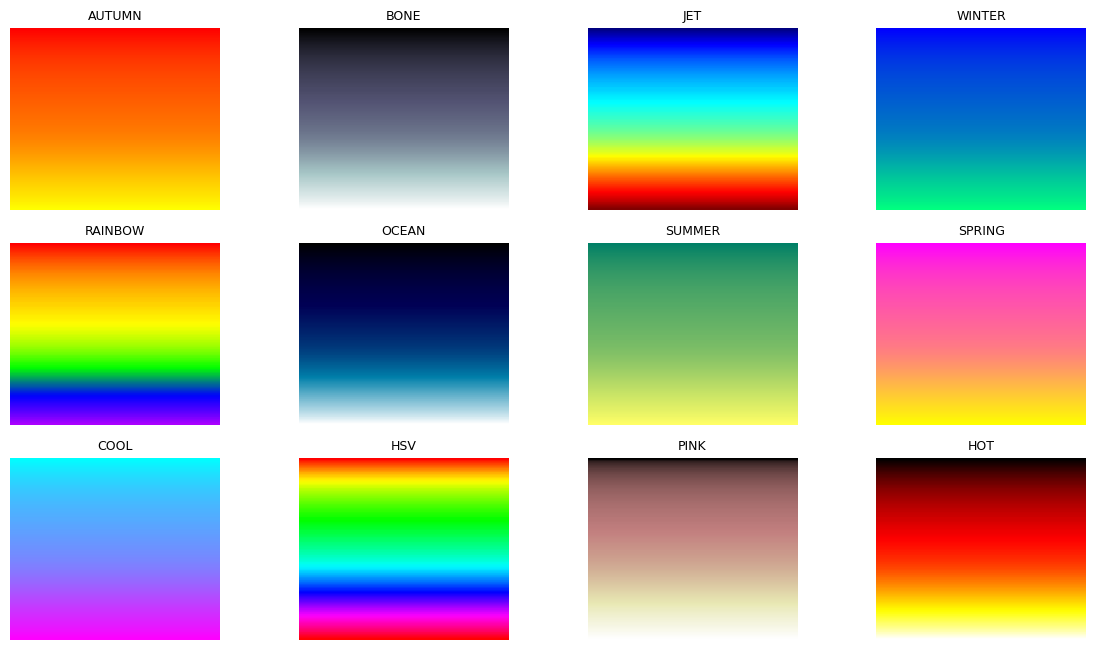

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

paletas = [
    ('AUTUMN', cv2.COLORMAP_AUTUMN),
    ('BONE',   cv2.COLORMAP_BONE),
    ('JET',    cv2.COLORMAP_JET),
    ('WINTER', cv2.COLORMAP_WINTER),
    ('RAINBOW',cv2.COLORMAP_RAINBOW),
    ('OCEAN',  cv2.COLORMAP_OCEAN),
    ('SUMMER', cv2.COLORMAP_SUMMER),
    ('SPRING', cv2.COLORMAP_SPRING),
    ('COOL',   cv2.COLORMAP_COOL),
    ('HSV',    cv2.COLORMAP_HSV),
    ('PINK',   cv2.COLORMAP_PINK),
    ('HOT',    cv2.COLORMAP_HOT),
]

# cargar imagen
img = cv2.imread('gradiente.png')

# convertir a gri
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray_u8 = cv2.normalize(gray, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

# carpeta 
out_dir = 'falso_color_outputs'
os.makedirs(out_dir, exist_ok=True)

# mostrar y guardar 
n = len(paletas)
cols = 4
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols*3, rows*2.2))
axes = axes.flatten()

for i, (name, cmap) in enumerate(paletas):
    colored = cv2.applyColorMap(gray_u8, cmap)     
    rgb = cv2.cvtColor(colored, cv2.COLOR_BGR2RGB)    

    axes[i].imshow(rgb)
    axes[i].set_title(name, fontsize=9)
    axes[i].axis('off')

    out_path = os.path.join(out_dir, f"{name}.png")
    plt.imsave(out_path, rgb)

for ax in axes[n:]:
    ax.axis('off')

plt.tight_layout()
plt.show()

SOLARIZACION

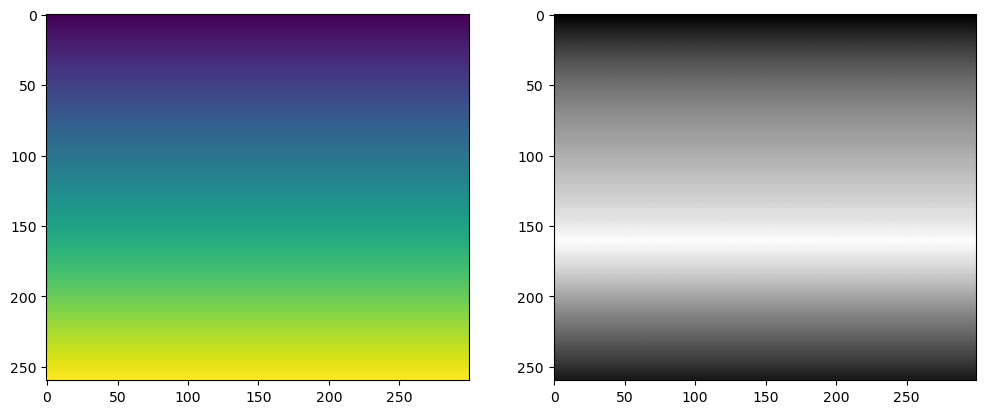

In [ ]:
import cv2
import numpy as np 
import matplotlib.pyplot as plt

def solarizar(imagen, umbral):
    img_sol=np.where(imagen<umbral,imagen,255-imagen)
    return img_sol

imagen= cv2.imread('gradiente.png')
img_gray=cv2.cvtColor(imagen,cv2.COLOR_BGR2GRAY)

umbral=127
img_fin=solarizar(img_gray,umbral)

plt.figure(figsize=(12,6))
plt.subplot(121)
plt.imshow(cv2.cvtColor(imagen,cv2.COLOR_BGR2RGB))
plt.subplot(122)
plt.imshow(img_fin,cmap='gray')
plt.show()

POSTERIZACION

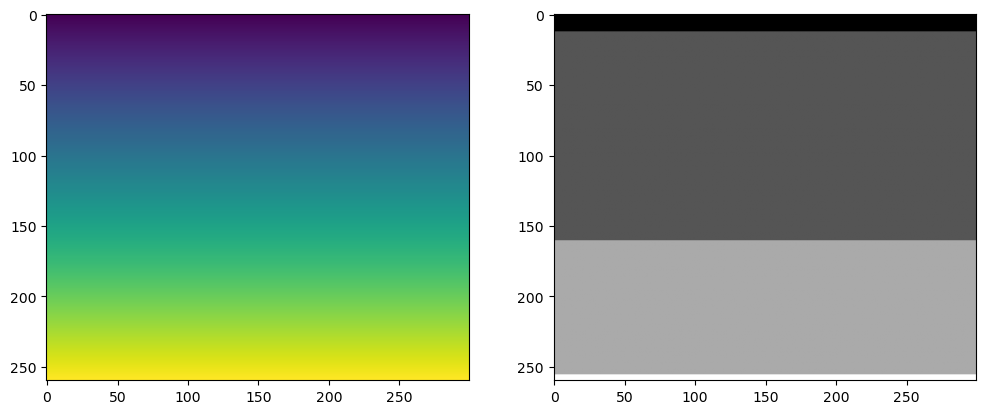

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def posterizar (imagen,niveles):
    factor_escala=255/niveles
    img_pos=np.round(imagen/factor_escala)*factor_escala
    return img_pos.astype(np.uint8)

imagen= cv2.imread('gradiente.png')
img_gray=cv2.cvtColor(imagen,cv2.COLOR_BGR2GRAY)
nvl=3
img_fin=posterizar(img_gray, nvl)
plt.figure(figsize=(12,6))
plt.subplot(121)
plt.imshow(cv2.cvtColor(imagen,cv2.COLOR_BGR2RGB))
plt.subplot(122)
plt.imshow(img_fin,cmap='gray')
plt.show()

## EJERCICIO 5

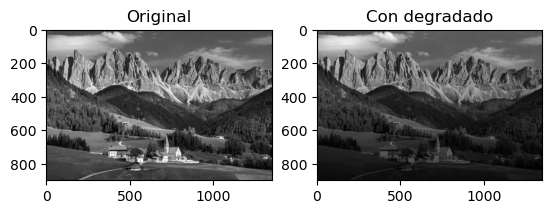

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.cvtColor(cv2.imread('imagen1.jpg'), cv2.COLOR_BGR2GRAY)

imgf = img.astype(np.float32)/255.0
h = imgf.shape[0]
mask = np.linspace(1, 0.2, h)[:, None]   
out = (imgf * mask).clip(0,1)

plt.subplot(1,2,1); 
plt.imshow(imgf, cmap='gray'); 
plt.title('Original')
plt.subplot(1,2,2); 
plt.imshow(out, cmap='gray');
plt.title('Con degradado')
plt.show()

## EJERCICIO 6

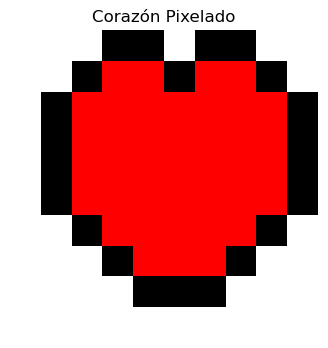

In [16]:
import numpy as np
import matplotlib.pyplot as plt

rows, cols = 10, 10

# Crear matriz base
grid = np.zeros((rows, cols, 3), dtype=np.uint8)

red = [255, 0, 0]
black = [0, 0, 0]
white = [255, 255, 255]

heart_pattern = [
    [0, 0, 0, 1, 1, 0, 1, 1, 0, 0],
    [0, 0, 1, 2, 2, 1, 2, 2, 1, 0],
    [0, 1, 2, 2, 2, 2, 2, 2, 2, 1],
    [0, 1, 2, 2, 2, 2, 2, 2, 2, 1],
    [0, 1, 2, 2, 2, 2, 2, 2, 2, 1],
    [0, 1, 2, 2, 2, 2, 2, 2, 2, 1],
    [0, 0, 1, 2, 2, 2, 2, 2, 1, 0],
    [0, 0, 0, 1, 2, 2, 2, 1, 0, 0],
    [0, 0, 0, 0, 1, 1, 1, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
]

# Pintar imagen
for i in range(rows):
    for j in range(cols):
        if heart_pattern[i][j] == 1:
            grid[i, j] = black
        elif heart_pattern[i][j] == 2:
            grid[i, j] = red
        else:
            grid[i, j] = white

# Mostrar
plt.figure(figsize=(4, 4))
plt.imshow(grid)
plt.title('Corazón Pixelado')
plt.axis('off')
plt.show()

# Guardar
plt.imsave('corazon.png', grid / 255.0)

# Filtro Bayer

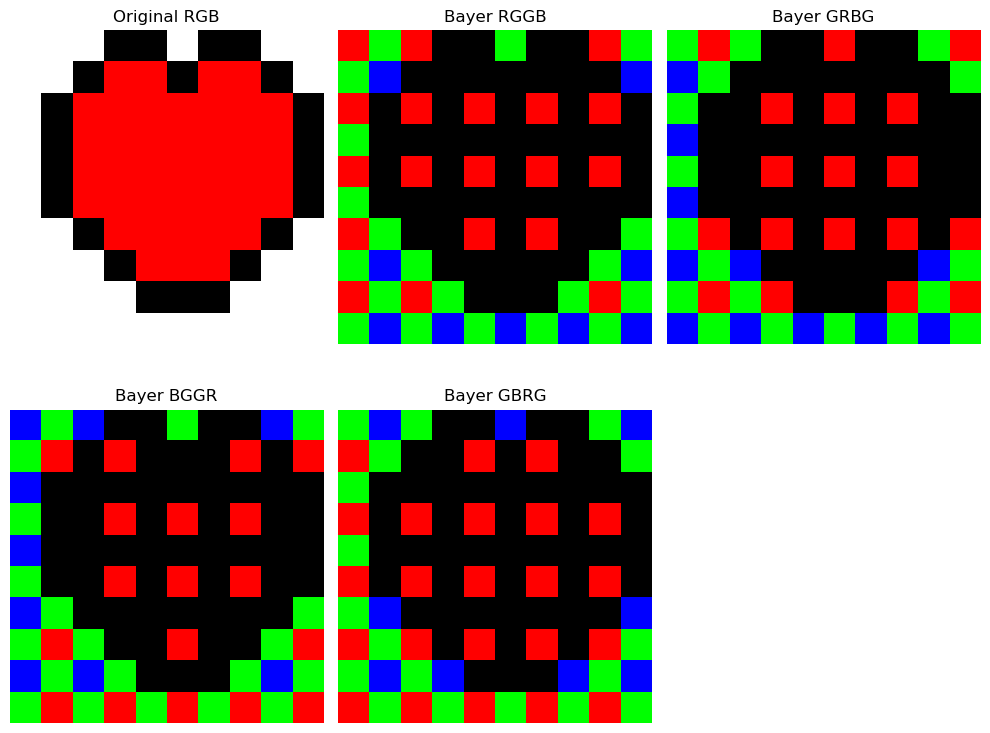

In [15]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Leer imagen y convertir a RGB
img_bgr = cv2.imread("corazon.png")
img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

h, w, _ = img.shape

def bayer_vectorized(img, pattern):
    out = np.zeros_like(img)
    if pattern == "RGGB":
        out[0::2, 0::2, 0] = img[0::2, 0::2, 0]   # R
        out[0::2, 1::2, 1] = img[0::2, 1::2, 1]   # G
        out[1::2, 0::2, 1] = img[1::2, 0::2, 1]   # G
        out[1::2, 1::2, 2] = img[1::2, 1::2, 2]   # B
    elif pattern == "GRBG":
        out[0::2, 0::2, 1] = img[0::2, 0::2, 1]   # G
        out[0::2, 1::2, 0] = img[0::2, 1::2, 0]   # R
        out[1::2, 0::2, 2] = img[1::2, 0::2, 2]   # B
        out[1::2, 1::2, 1] = img[1::2, 1::2, 1]   # G
    elif pattern == "BGGR":
        out[0::2, 0::2, 2] = img[0::2, 0::2, 2]   # B
        out[0::2, 1::2, 1] = img[0::2, 1::2, 1]   # G
        out[1::2, 0::2, 1] = img[1::2, 0::2, 1]   # G
        out[1::2, 1::2, 0] = img[1::2, 1::2, 0]   # R
    elif pattern == "GBRG":
        out[0::2, 0::2, 1] = img[0::2, 0::2, 1]   # G
        out[0::2, 1::2, 2] = img[0::2, 1::2, 2]   # B
        out[1::2, 0::2, 0] = img[1::2, 0::2, 0]   # R
        out[1::2, 1::2, 1] = img[1::2, 1::2, 1]   # G
    return out

patterns = ["RGGB", "GRBG", "BGGR", "GBRG"]

plt.figure(figsize=(10, 8))
# Original
plt.subplot(2, 3, 1)
plt.imshow(img)
plt.title("Original RGB")
plt.axis('off')

# Bayer
for i, p in enumerate(patterns):
    res = bayer_vectorized(img, p)
    plt.subplot(2, 3, i+2)
    plt.imshow(res)
    plt.title(f"Bayer {p}")
    plt.axis('off')
    plt.imsave(f"Bayer_{p}.png", res)

# Guardar original
plt.imsave("Original_RGB.png", img)

plt.tight_layout()
plt.show()